In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import os, glob, re, json, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SAVE_ROOT = "/content/drive/MyDrive/fire_proj/outputs_stage1"
MASTER_CSV = os.path.join(SAVE_ROOT, "stage1_results_master.csv")
ART_IDX    = os.path.join(SAVE_ROOT, "artifacts_index.csv")

assert os.path.exists(MASTER_CSV), f"Master CSV not found at {MASTER_CSV}"
assert os.path.exists(ART_IDX),    f"Missing {ART_IDX}"

dfm_all = pd.read_csv(MASTER_CSV)
print("Loaded master CSV with", len(dfm_all), "rows total")

dfm = dfm_all[dfm_all["condition"] == "clean"].copy()
print("Using clean condition only:", len(dfm), "rows")
display(dfm.head())


art_all = pd.read_csv(ART_IDX)


def get_artifacts(run_id: str, seed: int, condition: str = "clean"):
    rows = (art_all[(art_all["run_id"] == run_id) &
                    (art_all["seed"] == seed) &
                    (art_all["condition"] == condition)]
            .sort_values("timestamp"))
    if rows.empty:
        return None, None
    row = rows.iloc[-1]
    return row["npz_path"], row["ckpt_path"]

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded master CSV with 1400 rows total
Using clean condition only: 200 rows


,run_id,seed,trained_epochs,condition,test_auroc,test_auprc,test_ap_lift,n_test,acc@tau*,precision@tau*,recall@tau*,f1@tau*,bal_acc@tau*,acc@0.5,precision@0.5,recall@0.5,f1@0.5,bal_acc@0.5
3,Baseline,0,0,clean,0.552853,0.878533,0.016692,8939,0.861729,0.861907,0.999740,0.925721,0.500275,0.374091,0.886405,0.313993,0.463721,0.531490
10,Baseline,1,0,clean,0.256460,0.763086,-0.098756,8939,0.860387,0.861721,0.998183,0.924946,0.499496,0.155946,0.601017,0.061397,0.111412,0.403573
17,Baseline,2,0,clean,0.480776,0.847173,-0.014669,8939,0.861394,0.861942,0.999221,0.925518,0.500420,0.510684,0.859456,0.516745,0.645428,0.494810
24,Baseline,3,0,clean,0.567879,0.883386,0.021544,8939,0.860946,0.862204,0.998183,0.925224,0.501521,0.860275,0.863990,0.994418,0.924627,0.508950
31,Baseline,4,0,clean,0.514410,0.858787,-0.003055,8939,0.560130,0.869659,0.575935,0.692956,0.518737,0.194093,0.841530,0.079958,0.146041,0.493016


# Bar Graphs/Tables

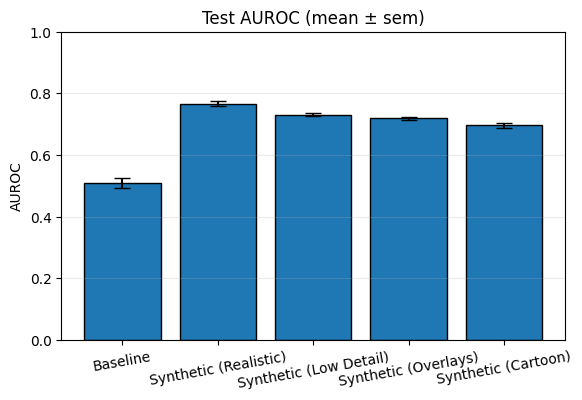

In [ ]:
# Map run_ids to human labels + fixed order
label_map = {
    "Baseline": "Baseline",
    "Synthetic_Realistic": "Synthetic (Realistic)",
    "Synthetic_Unrealistic": "Synthetic (Overlays)",
    "Synthetic_New_Unrealistic": "Synthetic (Low Detail)",
    "Synthetic_Overlays": "Synthetic (Cartoon)"
}


order = ["Baseline", "Synthetic (Realistic)", "Synthetic (Low Detail)", "Synthetic (Overlays)", "Synthetic (Cartoon)"]

df = dfm.copy()
df["run_label"] = df["run_id"].map(label_map).fillna(df["run_id"])
df["run_label"] = pd.Categorical(df["run_label"], categories=order, ordered=True)

def agg_stats(col):
    g = (df.groupby("run_label", observed=True)[col]
           .agg(["mean","sem"])
           .reindex(order))
    return g

def bar_with_err(stats_df, title, ylabel, ylim=(0,1)):
    x = np.arange(len(stats_df))
    means = stats_df["mean"].values
    errs  = stats_df["sem"].values
    plt.figure(figsize=(6.5,4))
    plt.bar(x, means, yerr=errs, capsize=6, edgecolor="black")
    plt.xticks(x, stats_df.index.tolist(), rotation=10)
    plt.ylabel(ylabel)
    if ylim is not None:
        plt.ylim(*ylim)
    plt.title(title)
    plt.grid(axis="y", alpha=0.25)
    plt.show()

# AUPRC
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd


# Threshold-free
bar_with_err(agg_stats("test_auroc"), "Test AUROC (mean ± sem)", "AUROC", ylim=(0,1.0))


In [ ]:

def agg_table(col, digits=4):
    """
    Return a table with n, mean, std, sem grouped by pretty run_label,
    ordered using your `order` list.
    """
    g = (df.groupby("run_label", observed=True)[col]
           .agg(n="count",
                mean="mean",
                std=lambda s: s.std(ddof=1),
                sem="sem")
           .reindex(order))
    # Neat rounding for display
    return g.round(digits)


auroc_table = agg_table("test_auroc")
print("\nTest AUROC (by run_label):")
print(auroc_table.to_string())




Test AUROC (by run_label):
                         n    mean     std     sem
run_label                                         
Baseline                40  0.5088  0.1072  0.0169
Synthetic (Realistic)   40  0.7671  0.0421  0.0067
Synthetic (Low Detail)  40  0.7304  0.0329  0.0052
Synthetic (Overlays)    40  0.6964  0.0510  0.0081
Synthetic (Cartoon)     40  0.7188  0.0383  0.0060


# Paired Differences

In [ ]:
# --- Paired tests vs Realistic (seed-matched) ---
from scipy import stats

# SETTINGS
REF_RUN_ID   = "Synthetic_Realistic"   # reference arm (by run_id)
METRIC       = "test_auroc"


# Work on a copy
df_pairs = dfm.copy()  # use the raw dfm to avoid label collisions; it has run_id, seed, and metrics

# Build seed x run_id pivot for the chosen metric (average if duplicates)
pt = (df_pairs
      .groupby(["seed","run_id"], observed=True)[METRIC]
      .mean()
      .unstack("run_id"))

# Decide which arms to compare
present_runs = pt.columns.tolist()
compare_runs = [r for r in present_runs if r != REF_RUN_ID]

rows = []
for arm in compare_runs:
    common = pt[[REF_RUN_ID, arm]].dropna()
    n = len(common)
    if n == 0:
        continue

    diffs = common[arm] - common[REF_RUN_ID]
    mean_diff = diffs.mean()
    std_diff  = diffs.std(ddof=1) if n > 1 else float("nan")
    sem_diff  = (std_diff / np.sqrt(n)) if n > 1 else float("nan")

    # Paired t-test
    t_p = stats.ttest_rel(common[arm], common[REF_RUN_ID]).pvalue if n >= 2 else float("nan")

    # Wilcoxon (only if there is at least one non-zero diff)
    try:
        if n >= 2 and np.any(diffs.to_numpy() != 0):
            w_p = stats.wilcoxon(common[arm], common[REF_RUN_ID], zero_method='wilcox').pvalue
        else:
            w_p = float("nan")
    except Exception:
        w_p = float("nan")

    rows.append({
        "metric": METRIC,
        "arm_run_id": arm,
        "n": n,
        "mean_diff": mean_diff,
        "std_diff": std_diff,
        "sem_diff": sem_diff,
        "t_p": t_p,
        "w_p": w_p
    })

paired_summary = (pd.DataFrame(rows)
                    .sort_values("mean_diff", ascending=False)
                    .reset_index(drop=True))

if "run_label" in df.columns:
    # Build run_id → run_label mapping
    id_to_label = (df[["run_id","run_label"]]
                   .drop_duplicates()
                   .set_index("run_id")["run_label"]
                   .to_dict())

    # Lookup labels
    ref_label = id_to_label.get(REF_RUN_ID, REF_RUN_ID)

    print(f"\nPaired differences vs {ref_label} (arm - {ref_label}) for metric '{METRIC}'")

    pretty = paired_summary.copy()
    pretty["arm_label"] = pretty["arm_run_id"].map(id_to_label).fillna(pretty["arm_run_id"])

    print(pretty[["metric","arm_label","n","mean_diff","std_diff","sem_diff","t_p","w_p"]]
          .to_string(index=False))





Paired differences vs Synthetic (Realistic) (arm - Synthetic (Realistic)) for metric 'test_auroc'
    metric                   arm_label  n  mean_diff  std_diff  sem_diff          t_p          w_p
test_auroc      Synthetic (Low Detail) 40  -0.036737  0.059006  0.009330 3.297941e-04 5.080382e-04
test_auroc         Synthetic (Cartoon) 40  -0.048273  0.062697  0.009913 1.888550e-05 2.639073e-05
test_auroc Synthetic (Simple Overlays) 40  -0.070675  0.070565  0.011157 1.778322e-07 1.163498e-07
test_auroc                    Baseline 40  -0.258258  0.112006  0.017710 2.229109e-17 1.818989e-12


# PR Curve

In [ ]:
import os, math, numpy as np, matplotlib.pyplot as plt
from sklearn.metrics import precision_recall_curve

# Build curves only from CLEAN artifacts
curves = {}
clean_rows = art_all[art_all.get("condition", "clean") == "clean"]  # robust if column missing

for _, row in clean_rows.iterrows():
    run_id, npz = row["run_id"], row["npz_path"]
    if str(run_id).startswith("Baseline"):
        continue
    if not isinstance(npz, str) or not os.path.exists(npz):
        continue

    data = np.load(npz, allow_pickle=True)
    y    = data["y_true"].astype(int)
    prob = data["p_pred"].astype(float)

    prec, rec, _ = precision_recall_curve(y, prob)  # rec is non-decreasing, may have duplicates

    # ---- Make recall strictly increasing; keep best precision at each recall ----
    order  = np.argsort(rec)                 # sort by recall ascending
    rec_s  = rec[order]
    prec_s = prec[order]

    uniq_rec = np.unique(rec_s).astype(float)
    max_prec = np.array([prec_s[rec_s == r].max() for r in uniq_rec], dtype=float)

    # store as (precision, recall)
    curves.setdefault(run_id, []).append((max_prec, uniq_rec))

# Interp helper (now recall is strictly increasing)
Rgrid = np.linspace(0, 1, 201)
def interp_prec_at_recall(prec, rec, grid):
    return np.interp(grid, rec, prec, left=prec[0], right=prec[-1])


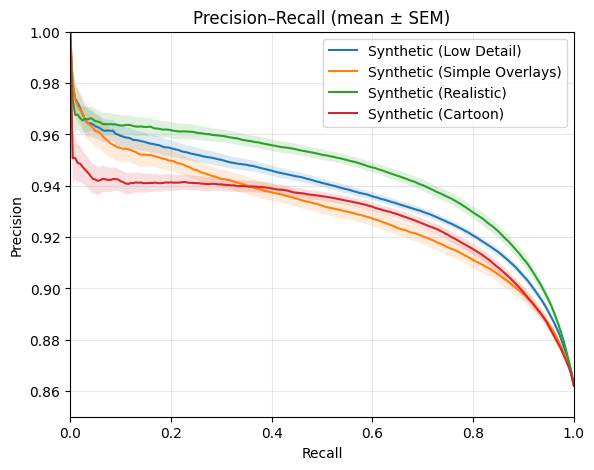

In [ ]:
EXCLUDE = {"Baseline", "Synthetic_Cartoon", "Synthetic_LowFidelity"}

label_map = {
    "Baseline": "Baseline",
    "Synthetic_Realistic": "Synthetic (Realistic)",
    "Synthetic_Unrealistic": "Synthetic (Cartoon)",
    "Synthetic_New_Unrealistic": "Synthetic (Low Detail)",
    "Synthetic_Overlays": "Synthetic (Simple Overlays)"
}
order = ["Baseline", "Synthetic (Realistic)", "Synthetic (Cartoon)", "Synthetic (Low Detail)", "Synthetic (Simple Overlays)"]

df = dfm.copy()
df["run_label"] = df["run_id"].map(label_map).fillna(df["run_id"])
df["run_label"] = pd.Categorical(df["run_label"], categories=order, ordered=True)

def agg_stats(col):
    g = (df.groupby("run_label", observed=True)[col]
           .agg(["mean","sem"])
           .reindex(order))
    return g

# Precompute AUPRC stats
auprc_stats = agg_stats("test_auprc")

plt.figure(figsize=(6.5, 5))
for run_id, pr_list in curves.items():
    if not pr_list or run_id in EXCLUDE:
        continue

    # Interpolate PR curves to a common recall grid for plotting only
    P_interp = np.stack([interp_prec_at_recall(p, r, Rgrid) for (p, r) in pr_list], axis=0)
    P_mean = P_interp.mean(axis=0)
    P_sem  = P_interp.std(axis=0, ddof=1) / math.sqrt(P_interp.shape[0]) if P_interp.shape[0] > 1 else np.zeros_like(P_mean)

    lbl = label_map.get(run_id, run_id)
    legend_lbl = lbl

    plt.plot(Rgrid, P_mean, label=legend_lbl)
    plt.fill_between(Rgrid, P_mean - P_sem, P_mean + P_sem, alpha=0.15)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision–Recall (mean ± SEM)")
plt.grid(alpha=0.3)
plt.legend()
plt.ylim(0.85, 1.0)
plt.xlim(0, 1.0)
plt.show()
